# Họ và Tên Phạm Hoàng Lợi
# MSSV  197ct22350

### Câu 1 (2 điểm): Cho một ảnh bất kỳ (tên ảnh do sinh viên tự đặt, ví dụ: `my_image.jpg`) và thực hiện các yêu cầu sau:

* Viết chương trình sử dụng Bilateral filter để làm mịn ảnh. (0.5 điểm)  
* Viết chương trình sử dụng Canny Edge Detection để xác định biên của hình ảnh. (0.5 điểm)  
* Đổi màu ảnh bằng cách hoán đổi kênh màu theo thứ tự (ví dụ: BGR → BRG) và lưu thành tên dạng `[ten_anh]_swapped.jpg`. (0.5 điểm)  
* Chuyển ảnh sang không gian màu YCrCb và tách riêng 3 kênh Y, Cr, Cb, lưu thành ảnh grayscale tương ứng (`[ten_anh]_Y.jpg`, `[ten_anh]_Cr.jpg`, `[ten_anh]_Cb.jpg`). (0.5 điểm)



--- Bắt đầu Tác vụ 4: Chuyển sang YCrCb và Tách Kênh (Hiển thị bằng Matplotlib) ---
   Đã chuyển đổi sang YCrCb và tách kênh.
   Kênh '4. Kênh Y (Độ chói)' đã lưu vào: bird_Y.jpeg
   Kênh '4. Kênh Cr (Độ đỏ)' đã lưu vào: bird_Cr.jpeg
   Kênh '4. Kênh Cb (Độ xanh)' đã lưu vào: bird_Cb.jpeg


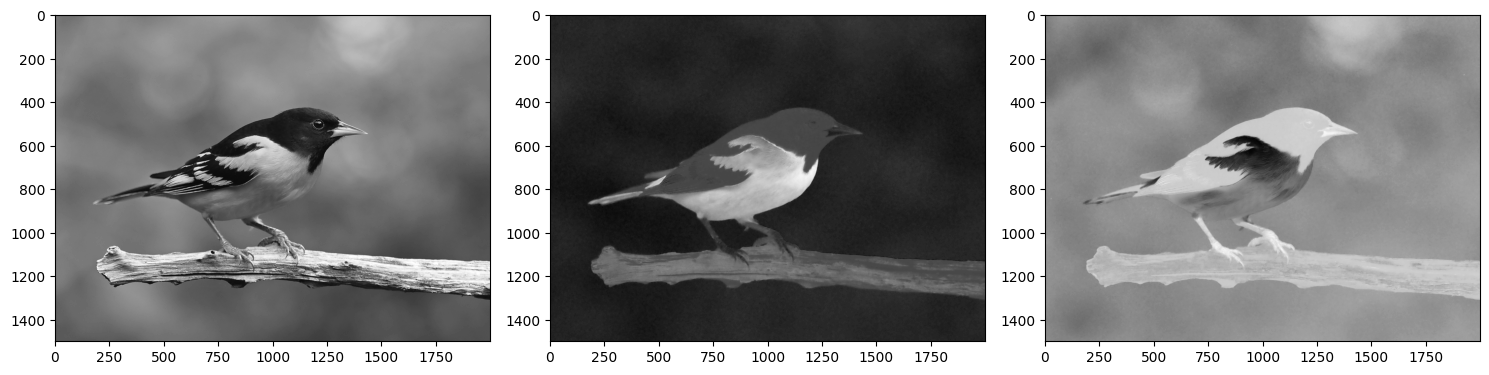

--- Kết thúc Tác vụ 4 ---


In [6]:
# Chuyển ảnh sang không gian màu YCrCb và tách riêng 3 kênh Y, Cr, Cb, lưu thành ảnh grayscale tương ứng (`[ten_anh]_Y.jpg`, `[ten_anh]_Cr.jpg`, `[ten_anh]_Cb.jpg`). (0.5 điểm)

import cv2
import os
import matplotlib.pyplot as plt


input_image_name = "bird.jpg"
base_name_without_ext = os.path.splitext(os.path.basename(input_image_name))[0]
output_y_path = f"{base_name_without_ext}_Y.jpeg"
output_cr_path = f"{base_name_without_ext}_Cr.jpeg"
output_cb_path = f"{base_name_without_ext}_Cb.jpeg"


def display_images_with_plt(images_data, titles, save_paths=None):
    if not images_data:
        print("Không có ảnh nào để hiển thị.")
        return

    num_images = len(images_data)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))

    if num_images == 1:
        axes = [axes]

    for i, (img, title) in enumerate(zip(images_data, titles)):
        if img is None:
            axes[i].set_title(f"Lỗi tải ảnh: {title}")
            axes[i].axis('off')
            continue

        if len(img.shape) == 3 and img.shape[2] == 3:
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img_display = img
           
            if len(img.shape) == 2:
                axes[i].imshow(img_display, cmap='gray')
                # Lưu ảnh grayscale nếu có đường dẫn
                if save_paths and save_paths[i]:
                    cv2.imwrite(save_paths[i], img_display)
                    print(f"   Kênh '{titles[i]}' đã lưu vào: {save_paths[i]}")
                continue # Bỏ qua imshow mặc định bên dưới

        axes[i].imshow(img_display)
        axes[i].set_title(title)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    

# --- Thực thi Tác vụ 4 ---
print("\n--- Bắt đầu Tác vụ 4: Chuyển sang YCrCb và Tách Kênh (Hiển thị bằng Matplotlib) ---")

# Kiểm tra sự tồn tại của ảnh đầu vào
if not os.path.exists(input_image_name):
    print(f"Lỗi: Tệp '{input_image_name}' không tìm thấy. Vui lòng đặt tệp ảnh vào cùng thư mục.")
else:
    img = cv2.imread(input_image_name)

    if img is None:
        print(f"Lỗi: Không thể đọc ảnh từ '{input_image_name}'.")
    else:
        # Chuyển đổi ảnh từ BGR sang YCrCb
        ycrcb_img = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)

        # Tách các kênh Y, Cr, Cb
        y_channel, cr_channel, cb_channel = cv2.split(ycrcb_img)

        print("   Đã chuyển đổi sang YCrCb và tách kênh.")
        display_images_with_plt(
            [y_channel, cr_channel, cb_channel],
            ["4. Kênh Y (Độ chói)", "4. Kênh Cr (Độ đỏ)", "4. Kênh Cb (Độ xanh)"],
            [output_y_path, output_cr_path, output_cb_path] # Lưu từng kênh
        )

print("--- Kết thúc Tác vụ 4 ---")


--- Bắt đầu Tác vụ 3: Hoán đổi Kênh màu (BGR sang RGB) (Hiển thị bằng Matplotlib) ---
   Đã hoán đổi kênh màu từ BGR sang RGB.


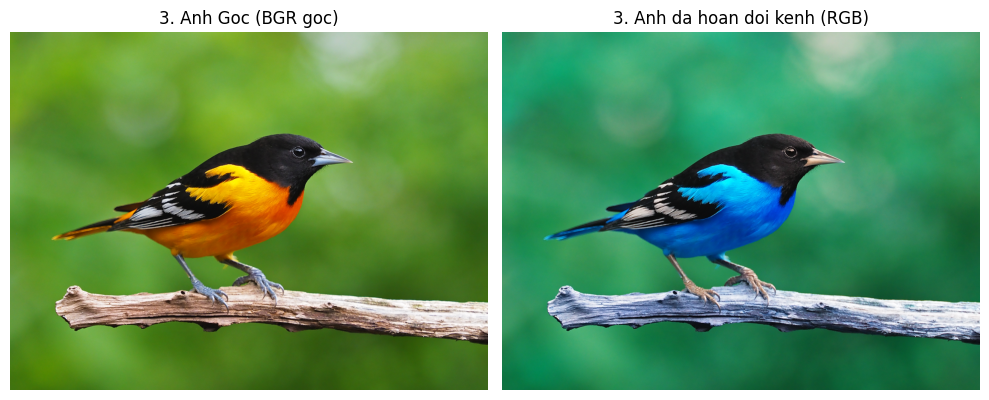

   Ảnh kết quả đã lưu vào: bird_swapped.jpg
--- Kết thúc Tác vụ 3 ---


In [5]:
# Đổi màu ảnh bằng cách hoán đổi kênh màu theo thứ tự (ví dụ: BGR → BRG) và lưu thành tên dạng `[ten_anh]_swapped.jpg`. (0.5 điểm) 
import cv2
import os
import matplotlib.pyplot as plt

# --- Cấu hình chung ---
input_image_name = "bird.jpg"
base_name_without_ext = os.path.splitext(os.path.basename(input_image_name))[0]
output_swapped_image = f"{base_name_without_ext}_swapped.jpg"

# --- Hàm trợ giúp để hiển thị ảnh bằng Matplotlib ---
def display_images_with_plt(images_data, titles, save_path=None):
    if not images_data:
        print("Không có ảnh nào để hiển thị.")
        return

    num_images = len(images_data)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))

    if num_images == 1:
        axes = [axes]

    for i, (img, title) in enumerate(zip(images_data, titles)):
        if img is None:
            axes[i].set_title(f"Lỗi tải ảnh: {title}")
            axes[i].axis('off')
            continue

        if len(img.shape) == 3 and img.shape[2] == 3:
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img_display = img

        axes[i].imshow(img_display)
        axes[i].set_title(title)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    if save_path:
        if images_data[-1] is not None:
            cv2.imwrite(save_path, images_data[-1])
            print(f"   Ảnh kết quả đã lưu vào: {save_path}")

# --- Thực thi Tác vụ 3 ---
print("\n--- Bắt đầu Tác vụ 3: Hoán đổi Kênh màu (BGR sang RGB) (Hiển thị bằng Matplotlib) ---")

# Kiểm tra sự tồn tại của ảnh đầu vào
if not os.path.exists(input_image_name):
    print(f"Lỗi: Tệp '{input_image_name}' không tìm thấy. Vui lòng đặt tệp ảnh vào cùng thư mục.")
else:
    img = cv2.imread(input_image_name)

    if img is None:
        print(f"Lỗi: Không thể đọc ảnh từ '{input_image_name}'.")
    else:
    
        swapped_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 


        print("   Đã hoán đổi kênh màu từ BGR sang RGB.")
        display_images_with_plt(
            [img, swapped_img], 
            ["3. Anh Goc (BGR goc)", "3. Anh da hoan doi kenh (RGB)"],
            output_swapped_image 
        )

print("--- Kết thúc Tác vụ 3 ---")


--- Bắt đầu Tác vụ 2: Xác định biên bằng Canny Edge Detection (Hiển thị bằng Matplotlib) ---
   Đã áp dụng Canny Edge Detection.


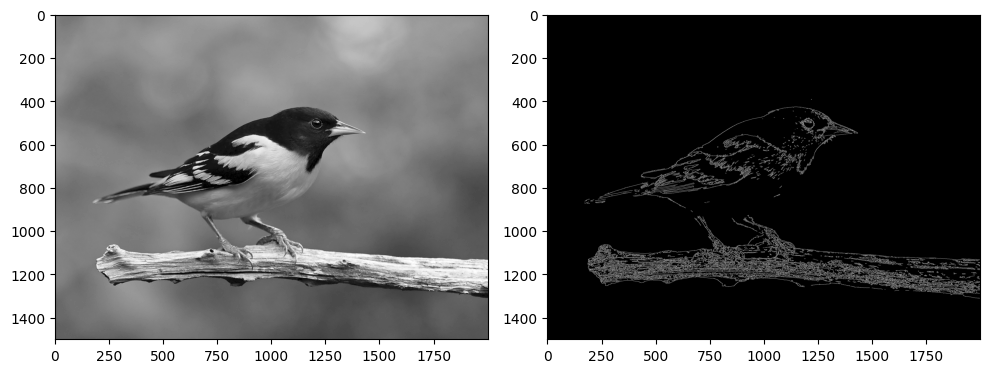

   Ảnh kết quả đã lưu vào: bird_canny_edges.jpg
--- Kết thúc Tác vụ 2 ---


In [4]:
#Viết chương trình sử dụng Canny Edge Detection để xác định biên của hình ảnh. (0.5 điểm) 
import cv2
import os
import matplotlib.pyplot as plt

input_image_name = "bird.jpg"
output_canny_image = os.path.splitext(os.path.basename(input_image_name))[0] + "_canny_edges.jpg"


def display_images_with_plt(images_data, titles, save_path=None):
    if not images_data:
        print("Không có ảnh nào để hiển thị.")
        return

    num_images = len(images_data)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))

    if num_images == 1:
        axes = [axes]

    for i, (img, title) in enumerate(zip(images_data, titles)):
        if img is None:
            axes[i].set_title(f"Lỗi tải ảnh: {title}")
            axes[i].axis('off')
            continue

        if len(img.shape) == 3 and img.shape[2] == 3:
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img_display = img
           
            if len(img.shape) == 2:
                axes[i].imshow(img_display, cmap='gray')
                continue 

        axes[i].imshow(img_display)
        axes[i].set_title(title)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    if save_path:
        if images_data[-1] is not None:
            cv2.imwrite(save_path, images_data[-1])
            print(f"   Ảnh kết quả đã lưu vào: {save_path}")

print("\n--- Bắt đầu Tác vụ 2: Xác định biên bằng Canny Edge Detection (Hiển thị bằng Matplotlib) ---")


if not os.path.exists(input_image_name):
    print(f"Lỗi: Tệp '{input_image_name}' không tìm thấy. Vui lòng đặt tệp ảnh vào cùng thư mục.")
else:

    img_gray = cv2.imread(input_image_name, cv2.IMREAD_GRAYSCALE)

    if img_gray is None:
        print(f"Lỗi: Không thể đọc ảnh từ '{input_image_name}'.")
    else:
        
        edges = cv2.Canny(img_gray, threshold1=100, threshold2=200)

        print("   Đã áp dụng Canny Edge Detection.")
        display_images_with_plt(
            [img_gray, edges],
            ["2. Anh Goc (Xam)", "2. Anh Canh Canny"],
            output_canny_image 
        )

print("--- Kết thúc Tác vụ 2 ---")


--- Bắt đầu Tác vụ 1: Làm mịn ảnh bằng Bilateral Filter (Hiển thị bằng Matplotlib) ---
   Đã áp dụng Bilateral Filter.


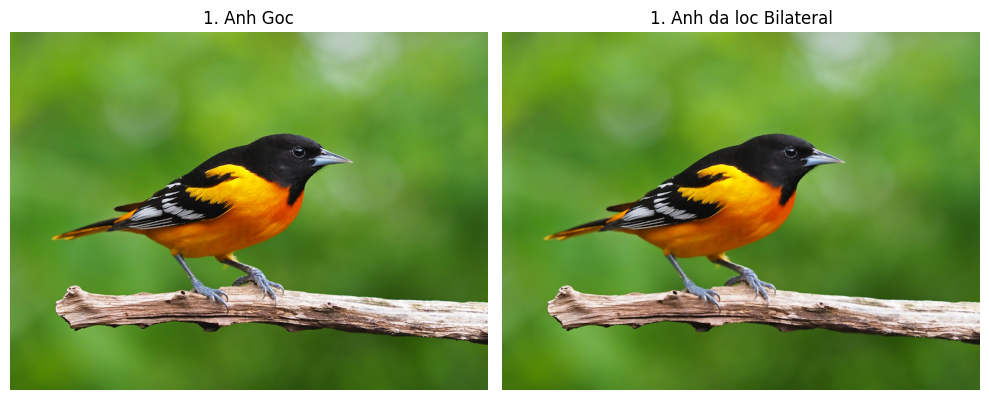

   Ảnh kết quả đã lưu vào: bird_bilateral_filtered.jpg
--- Kết thúc Tác vụ 1 ---


In [ ]:
 # Viết chương trình sử dụng Bilateral filter để làm mịn ảnh. (0.5 điểm)  

import cv2
import os
import matplotlib.pyplot as plt

input_image_name = "bird.jpg"
output_bilateral_image = os.path.splitext(os.path.basename(input_image_name))[0] + "_bilateral_filtered.jpg"

def display_images_with_plt(images_data, titles, save_path=None):
    """
    Hiển thị nhiều ảnh trong một figure bằng Matplotlib.
    Args:
        images_data (list of numpy.ndarray): Danh sách các ảnh cần hiển thị.
        titles (list of str): Danh sách các tiêu đề tương ứng cho mỗi ảnh.
        save_path (str, optional): Đường dẫn để lưu ảnh đầu ra cuối cùng (nếu có).
    """
    if not images_data:
        print("Không có ảnh nào để hiển thị.")
        return

    num_images = len(images_data)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5)) 

    
    if num_images == 1:
        axes = [axes]

    for i, (img, title) in enumerate(zip(images_data, titles)):
        if img is None:
            axes[i].set_title(f"Lỗi tải ảnh: {title}")
            axes[i].axis('off')
            continue

        if len(img.shape) == 3 and img.shape[2] == 3:
            img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            img_display = img 

        axes[i].imshow(img_display)
        axes[i].set_title(title)
        axes[i].axis('off') 

    plt.tight_layout() 
    plt.show()

    if save_path:
        
        if images_data[-1] is not None:
            cv2.imwrite(save_path, images_data[-1])
            print(f"   Ảnh kết quả đã lưu vào: {save_path}")


print("\n--- Bắt đầu Tác vụ 1: Làm mịn ảnh bằng Bilateral Filter (Hiển thị bằng Matplotlib) ---")


if not os.path.exists(input_image_name):
    print(f"Lỗi: Tệp '{input_image_name}' không tìm thấy. Vui lòng đặt tệp ảnh vào cùng thư mục.")
else:
    img = cv2.imread(input_image_name)

    if img is None:
        print(f"Lỗi: Không thể đọc ảnh từ '{input_image_name}'.")
    else:
        
        filtered_img = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

        print("   Đã áp dụng Bilateral Filter.")
        display_images_with_plt(
            [img, filtered_img],
            ["1. Anh Goc", "1. Anh da loc Bilateral"],
            output_bilateral_image 
        )

print("--- Kết thúc Tác vụ 1 ---")

### Câu 2 (4 điểm) Viết một chương trình Python sử dụng OpenCV để tạo menu tương tác cho phép người dùng chọn các kỹ thuật biến đổi hình học và xử lý ảnh nâng cao từ một danh sách, áp dụng đồng thời cho nhiều ảnh.

### Yêu cầu:

1. Menu gồm:  
* Phóng to ảnh (Zoom bằng resize) (0.5 điểm)  
* Xoay ảnh (góc ngẫu nhiên từ 0–360 độ) (0.5 điểm)  
* Lật ảnh ngang (0.5 điểm)  
* Lật ảnh dọc (0.5 điểm)  
* Cắt ảnh (crop ngẫu nhiên vùng giữa ảnh) (0.5 điểm)  
* Thêm viền (padding màu ngẫu nhiên) (0.5 điểm)

2. Chương trình xử lý đồng thời 3 ảnh bất kỳ do sinh viên tự chọn (có thể chọn bằng đường dẫn file hoặc nhập tên ảnh tùy ý). (0.5 điểm)

3. Phím tương ứng để kích hoạt các phương pháp xử lý:  
* Z: Zoom  
* T: Rotate  
* H: Horizontal Flip  
* V: Vertical Flip  
* C: Crop  
* P: Padding (0.5 điểm)

4. Lưu file kết quả với định dạng: `result_[phương pháp]_[tên ảnh gốc].jpg`  
   Ví dụ: `result_crop_cat.jpg`, `result_rotate_image1.jpg` (0.5 điểm)


Chào mừng đến với Công cụ xử lý ảnh!
Vui lòng chọn 3 tệp ảnh khi được nhắc.
Bạn đã chọn 0 ảnh. Vui lòng chọn CHÍNH XÁC 3 ảnh.
Bạn phải chọn chính xác 3 ảnh. Vui lòng thử lại.
Bạn đã chọn 0 ảnh. Vui lòng chọn CHÍNH XÁC 3 ảnh.
Bạn phải chọn chính xác 3 ảnh. Vui lòng thử lại.

--- Menu ---
Nhấn 'z' để Thu phóng (Zoom)
Nhấn 't' để Xoay (Rotate)
Nhấn 'h' để Lật ngang (Horizontal Flip)
Nhấn 'v' để Lật dọc (Vertical Flip)
Nhấn 'c' để Cắt ảnh (Crop)
Nhấn 'p' để Thêm viền (Padding)
Nhấn 'r' để Đặt lại ảnh về trạng thái gốc
Nhấn 's' để Lưu các ảnh đã xử lý hiện tại
Nhấn 'q' để Thoát (đóng cửa sổ ảnh)


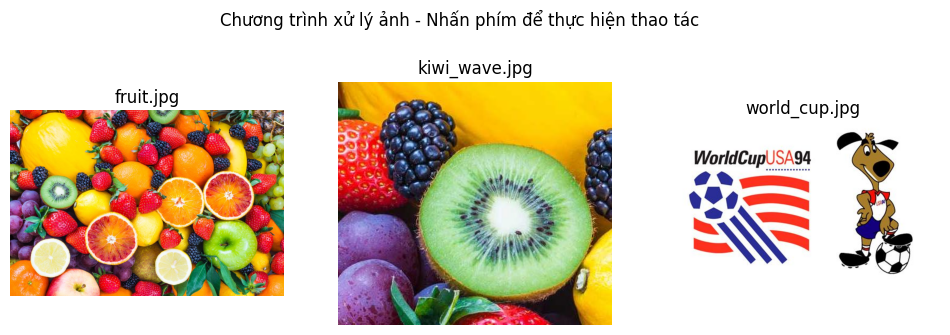

In [ ]:
import cv2
import numpy as np
import random
import os
from tkinter import Tk, filedialog
import matplotlib.pyplot as plt

# Global variables to manage images and state
original_images = []
processed_images = []
image_names = []
active_method = None
fig = None # Matplotlib figure
axs = None # Matplotlib axes
is_running = True # Flag to control program execution

def load_images_from_dialog():
    """Opens a file dialog to select multiple images."""
    root = Tk()
    root.withdraw() # Hide the main window
    file_paths = filedialog.askopenfilenames(
        title="Chọn 3 ảnh để xử lý",
        filetypes=[("Tệp ảnh", "*.jpg *.jpeg *.png *.bmp *.tiff")]
    )
    if len(file_paths) != 3:
        print(f"Bạn đã chọn {len(file_paths)} ảnh. Vui lòng chọn CHÍNH XÁC 3 ảnh.")
        return []
    return list(file_paths)

def apply_zoom(image, zoom_factor):
    """Applies zoom to an image."""
    height, width = image.shape[:2]
    new_width, new_height = int(width * zoom_factor), int(height * zoom_factor)
    return cv2.resize(image, (new_width, new_height), interpolation=cv2.INTER_LINEAR)

def apply_rotate(image, angle):
    """Applies rotation to an image."""
    height, width = image.shape[:2]
    center = (width // 2, height // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    # The output size of warpAffine should be (width, height)
    return cv2.warpAffine(image, M, (width, height))

def apply_flip_horizontal(image):
    """Applies horizontal flip to an image."""
    return cv2.flip(image, 1)

def apply_flip_vertical(image):
    """Applies vertical flip to an image."""
    return cv2.flip(image, 0)

def apply_crop(image):
    """Applies a random crop from the middle of the image."""
    height, width = image.shape[:2]
    # Ensure crop size is reasonable, e.g., 50-90% of original size
    crop_factor = random.uniform(0.5, 0.9)
    crop_width = int(width * crop_factor)
    crop_height = int(height * crop_factor)

    start_x = (width - crop_width) // 2
    start_y = (height - crop_height) // 2

    if crop_width <= 0 or crop_height <= 0: # Handle edge case for very small crops
        print("Cảnh báo: Kích thước cắt quá nhỏ, trả về ảnh gốc.")
        return image # Return original if crop dimensions become non-positive

    end_x = start_x + crop_width
    end_y = start_y + crop_height

    # Ensure crop coordinates are within image bounds
    start_x = max(0, start_x)
    start_y = max(0, start_y)
    end_x = min(width, end_x)
    end_y = min(height, end_y)

    return image[start_y:end_y, start_x:end_x]

def apply_padding(image):
    """Applies random padding to an image."""
    height, width = image.shape[:2]
    # Random padding amounts for each side
    top_pad = random.randint(20, 100)
    bottom_pad = random.randint(20, 100)
    left_pad = random.randint(20, 100)
    right_pad = random.randint(20, 100)

    # Random border color (B, G, R)
    border_color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

    return cv2.copyMakeBorder(image, top_pad, bottom_pad, left_pad, right_pad,
                              cv2.BORDER_CONSTANT, value=border_color)

def update_display():
    """Updates the matplotlib figure with current processed images."""
    global fig, axs, processed_images, image_names

    if not processed_images:
        print("Không có ảnh để hiển thị.")
        return

    # Create figure and axes if they don't exist
    if fig is None or axs is None or not plt.fignum_exists(fig.number):
        fig, axs = plt.subplots(1, len(processed_images), figsize=(12, 4))
        if len(processed_images) == 1: # If only one image, axs is not an array
            axs = [axs]
        fig.suptitle("Chương trình xử lý ảnh - Nhấn phím để thực hiện thao tác")
    else:
        for ax in axs:
            ax.clear() # Clear existing content

    for i, img in enumerate(processed_images):
        # Convert BGR (OpenCV) to RGB (Matplotlib)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img_rgb)
        axs[i].set_title(image_names[i])
        axs[i].axis('off') # Hide axes ticks and labels

    fig.canvas.draw_idle() # Redraw the figure
    # plt.pause(0.001) # Small pause to allow GUI to update

def on_key_press(event):
    """Handles key press events for image processing."""
    global active_method, processed_images, original_images, image_names, fig, is_running

    if not is_running: # Stop processing if quit
        return

    print(f"Phím đã nhấn: {event.key}")

    # Make a copy of original images for processing to avoid modifying them directly
    # This ensures each new operation starts from the original state of the image.
    current_originals = [img.copy() for img in original_images]

    if event.key == 'z':
        active_method = "zoom"
        zoom_factor = random.uniform(0.8, 1.5) # Random zoom between 80% and 150%
        print(f"Áp dụng Thu phóng (hệ số: {zoom_factor:.2f})...")
        for i in range(len(processed_images)):
            processed_images[i] = apply_zoom(current_originals[i], zoom_factor)
        print("Thu phóng đã áp dụng. Nhấn 's' để lưu hoặc chọn thao tác khác.")
    elif event.key == 't':
        active_method = "rotate"
        angle = random.randint(0, 360)
        print(f"Áp dụng Xoay (góc: {angle} độ)...")
        for i in range(len(processed_images)):
            processed_images[i] = apply_rotate(current_originals[i], angle)
        print("Xoay đã áp dụng. Nhấn 's' để lưu hoặc chọn thao tác khác.")
    elif event.key == 'h':
        active_method = "horizontal_flip"
        print("Áp dụng Lật ngang...")
        for i in range(len(processed_images)):
            processed_images[i] = apply_flip_horizontal(current_originals[i])
        print("Lật ngang đã áp dụng. Nhấn 's' để lưu hoặc chọn thao tác khác.")
    elif event.key == 'v':
        active_method = "vertical_flip"
        print("Áp dụng Lật dọc...")
        for i in range(len(processed_images)):
            processed_images[i] = apply_flip_vertical(current_originals[i])
        print("Lật dọc đã áp dụng. Nhấn 's' để lưu hoặc chọn thao tác khác.")
    elif event.key == 'c':
        active_method = "crop"
        print("Áp dụng Cắt ảnh...")
        for i in range(len(processed_images)):
            processed_images[i] = apply_crop(current_originals[i])
        print("Cắt ảnh đã áp dụng. Nhấn 's' để lưu hoặc chọn thao tác khác.")
    elif event.key == 'p':
        active_method = "padding"
        print("Áp dụng Thêm viền...")
        for i in range(len(processed_images)):
            processed_images[i] = apply_padding(current_originals[i])
        print("Thêm viền đã áp dụng. Nhấn 's' để lưu hoặc chọn thao tác khác.")
    elif event.key == 'r': # Reset to original images
        print("Đặt lại ảnh về trạng thái gốc...")
        processed_images[:] = [img.copy() for img in original_images] # Reset using slice assignment
        active_method = None
    elif event.key == 's':
        if active_method:
            print("Đang lưu ảnh đã xử lý...")
            for i, img in enumerate(processed_images):
                original_name = os.path.splitext(image_names[i])[0]
                save_filename = f"result_{active_method}_{original_name}.jpg"
                cv2.imwrite(save_filename, img)
                print(f"Đã lưu: {save_filename}")
            print("Ảnh đã lưu. Bạn có thể chọn thao tác khác hoặc nhấn 'q' để thoát.")
            # After saving, reset to original images for new operations
            processed_images[:] = [img.copy() for img in original_images]
            active_method = None
        else:
            print("Chưa có thao tác nào được áp dụng. Vui lòng áp dụng thao tác trước khi lưu.")
    elif event.key == 'q':
        print("Đang thoát chương trình.")
        is_running = False # Set flag to stop execution
        if fig:
            plt.close(fig) # Close the matplotlib window
        return # Exit the event handler

    update_display() # Update the display after any operation

if __name__ == "__main__":
    print("Chào mừng đến với Công cụ xử lý ảnh!")
    print("Vui lòng chọn 3 tệp ảnh khi được nhắc.")

    plt.ion() # Turn on interactive mode for Matplotlib

    image_paths = []
    
    while len(image_paths) != 3:
        image_paths = load_images_from_dialog()
        if len(image_paths) != 3:
            print("Bạn phải chọn chính xác 3 ảnh. Vui lòng thử lại.")

    for path in image_paths:
        img = cv2.imread(path)
        if img is None:
            print(f"Lỗi: Không thể tải ảnh {path}. Vui lòng kiểm tra đường dẫn tệp.")
            exit()
        original_images.append(img)
        image_names.append(os.path.basename(path))

    
    processed_images = [img.copy() for img in original_images]

    print("\n--- Menu ---")
    print("Nhấn 'z' để Thu phóng (Zoom)")
    print("Nhấn 't' để Xoay (Rotate)")
    print("Nhấn 'h' để Lật ngang (Horizontal Flip)")
    print("Nhấn 'v' để Lật dọc (Vertical Flip)")
    print("Nhấn 'c' để Cắt ảnh (Crop)")
    print("Nhấn 'p' để Thêm viền (Padding)")
    print("Nhấn 'r' để Đặt lại ảnh về trạng thái gốc")
    print("Nhấn 's' để Lưu các ảnh đã xử lý hiện tại")
    print("Nhấn 'q' để Thoát (đóng cửa sổ ảnh)")

    
    update_display()

    
    if fig: 
        fig.canvas.mpl_connect('key_press_event', on_key_press)

    
    plt.ioff()
    plt.show() 

### Câu 3 (4 điểm) Viết một chương trình Python để xử lý 3 ảnh bất kỳ do sinh viên tự chọn.

* Thêm viền đen 20 pixel cho ảnh đầu tiên. (0.5 điểm)  
* Xoay ảnh thứ hai 45 độ và phóng to 1.5 lần. (0.5 điểm)  
* Tăng kích thước ảnh thứ ba lên 4 lần, sau đó áp dụng Bilateral Filter với tham số tùy chọn. (1.5 điểm)  
* Thay đổi độ sáng và độ tương phản ảnh thứ ba theo công thức:

$$
I_{out}(x, y) = \alpha \cdot I_{in}(x, y) + \beta
$$

Trong đó:  

$$
\alpha \in [0.6, 2.0], \quad \beta \in [-60, 60]
$$

Giá trị đầu ra cần được giới hạn trong khoảng [0, 255] bằng công thức:

$$
I_{out}(x, y) = \text{clip}(I_{out}(x, y), 0, 255)
$$


Processed: Added border to world_cup.jpg
Processed: Rotated and zoomed fruit.jpg
Processed: Resized, filtered, and adjusted brightness/contrast for kiwi_wave.jpg


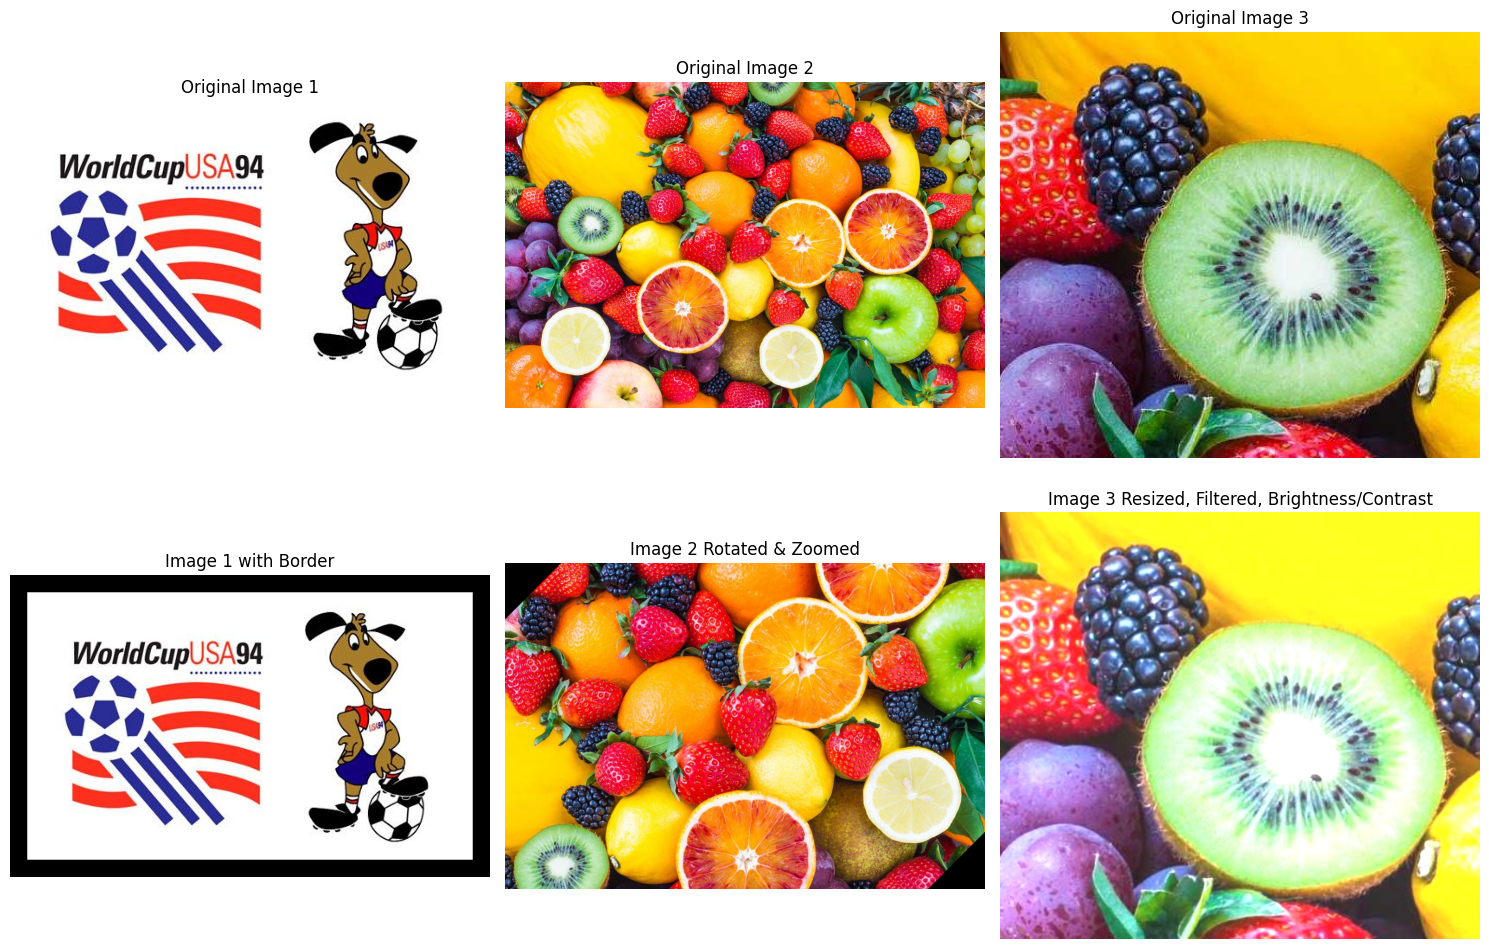

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_paths = ["world_cup.jpg", "fruit.jpg", "kiwi_wave.jpg"]


original_img1 = cv2.imread(image_paths[0])
original_img2 = cv2.imread(image_paths[1])
original_img3 = cv2.imread(image_paths[2])


if original_img1 is None:
    print(f"Error: Could not load {image_paths[0]}")
    exit()
if original_img2 is None:
    print(f"Error: Could not load {image_paths[1]}")
    exit()
if original_img3 is None:
    print(f"Error: Could not load {image_paths[2]}")
    exit()


processed_images = {}


try:
    border_size = 20
    img1_with_border = cv2.copyMakeBorder(original_img1, border_size, border_size, border_size, border_size,
                                          cv2.BORDER_CONSTANT, value=[0, 0, 0]) 
    processed_images['img1_border'] = img1_with_border
    print(f"Processed: Added border to {image_paths[0]}")
except Exception as e:
    print(f"Error processing {image_paths[0]} for border: {e}")
    processed_images['img1_border'] = original_img1 

try:
    (h, w) = original_img2.shape[:2]
    center = (w // 2, h // 2)
    
   
    M_rotate = cv2.getRotationMatrix2D(center, 45, 1.5) 
    img2_rotated_zoomed = cv2.warpAffine(original_img2, M_rotate, (w, h))
    processed_images['img2_rotated_zoomed'] = img2_rotated_zoomed
    print(f"Processed: Rotated and zoomed {image_paths[1]}")
except Exception as e:
    print(f"Error processing {image_paths[1]} for rotation/zoom: {e}")
    processed_images['img2_rotated_zoomed'] = original_img2 


try:
    
    scale_factor = 4
    new_width = int(original_img3.shape[1] * scale_factor)
    new_height = int(original_img3.shape[0] * scale_factor)
    img3_resized = cv2.resize(original_img3, (new_width, new_height), interpolation=cv2.INTER_LINEAR)

    
    img3_filtered = cv2.bilateralFilter(img3_resized, d=9, sigmaColor=75, sigmaSpace=75)

    
    alpha = 1.2 
    beta = 30   

    img3_processed = cv2.convertScaleAbs(img3_filtered, alpha=alpha, beta=beta)
    processed_images['img3_full_process'] = img3_processed
    print(f"Processed: Resized, filtered, and adjusted brightness/contrast for {image_paths[2]}")
except Exception as e:
    print(f"Error processing {image_paths[2]} for full process: {e}")
    processed_images['img3_full_process'] = original_img3 



plt.figure(figsize=(15, 10))

# Image 1
plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(original_img1, cv2.COLOR_BGR2RGB))
plt.title("Original Image 1")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(processed_images['img1_border'], cv2.COLOR_BGR2RGB))
plt.title("Image 1 with Border")
plt.axis('off')

# Image 2
plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(original_img2, cv2.COLOR_BGR2RGB))
plt.title("Original Image 2")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(processed_images['img2_rotated_zoomed'], cv2.COLOR_BGR2RGB))
plt.title("Image 2 Rotated & Zoomed")
plt.axis('off')

# Image 3
plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(original_img3, cv2.COLOR_BGR2RGB))
plt.title("Original Image 3")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(processed_images['img3_full_process'], cv2.COLOR_BGR2RGB))
plt.title("Image 3 Resized, Filtered, Brightness/Contrast")
plt.axis('off')

plt.tight_layout()
plt.show()


# Chúc các bạn thi may mắn và đạt điểm 10.